# 05 — Tap–Motion Coupling

## The physical idea

A tap is an impact. Newton's third law: the finger striking the glass pushes the handset
away, so every `touchstart` should leave a small impulse in the accelerometer.

If that impulse is measurable, its **shape** encodes things no timing feature can reach —
how hard someone strikes, how firmly they grip, whether the phone is held loosely in the
hand or braced against something. Timing tells you *when* a person tapped. This tells you
*how*.

This is the only place in the project where two sensor streams are coupled rather than
analysed separately, which is why it gets its own notebook — and why it fails in its own
distinct way. Motion can drop out while touch timing stays perfect, so this modality has an
availability problem neither of its parents has.

## What one tap physically produces

```
    finger approaches        contact          handset rings down
    ────────────────▶   ▓▓▓▓▓▓▓▓▓▓▓▓   ～～～～～～～～～～～▶
      (hand steadies)      (impulse)      (decay depends on grip)
         ~175ms before       ~25ms           ~250ms after
```

Three phases, each meaning something different:

- **Before contact** — does the hand still itself in preparation? A steadying dip here is a
  motor-planning signature, not an artifact of the strike.
- **At contact** — the impulse magnitude: how much momentum the finger transferred.
- **After contact** — the ring-down: how quickly the oscillation dies. This is grip
  firmness. A loosely held phone rings; a braced one damps immediately.

## What this notebook does

Establishes that the impulse is real (against a hard control), shows what it looks like at
the level of individual taps rather than only averages, breaks it into features with
physical meaning, and then interrogates the two confounds that could explain it away — pace
and handset.

It does **not** score features, rank them, or decide what goes into a model. Where the
original version of this notebook computed a discriminability number, this one plots the
distributions that number was summarising.

## Sections

1. Setup
2. What 20 Hz can actually resolve
3. Motion availability around taps
4. Is there an impulse at all? — the existence test
5. Individual taps, not averages
6. Every participant's own impulse shape
7. The three-phase signature
8. Per-tap features and their distributions
9. Which features are actually different from each other
10. Which axis carries the impulse
11. Does the impulse depend on the tap's context?
12. Is it just measuring pace?
13. Is it just measuring the handset?
14. Availability — who can be measured
15. Data-quality notes and rejected derivations
16. Per-participant cards
17. Open questions

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/raw_events.parquet",
               "data/processed/raw_events.parquet",
               "raw_events.parquet",
               "/mnt/user-data/uploads/raw_events.parquet"]
_src = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _src is None:
    raise FileNotFoundError(f"no raw events file found; tried {_CANDIDATES}")
raw_all = pd.read_parquet(_src)
raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

TAP, MOTION = 'touchstart', 'devicemotion'
ACC = ['payload_ax', 'payload_ay', 'payload_az']

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                 .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      started=('timestampIso', 'min')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['session_no'] = session_index.groupby('participantId').cumcount() + 1
SESSION_LABEL = {r.sessionId: f"{r.participantId} s{r.session_no}" for r in session_index.itertuples()}
SESSION_ORDER = session_index.sort_values(['participantId', 'session_no'])['sessionId'].tolist()

_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANTS = _p_dur.index.astype(str).tolist()
_QUAL = plt.get_cmap('tab10')
PCOL = {p: _QUAL(i % 10) for i, p in enumerate(PARTICIPANTS)}
def pcolor(p): return PCOL.get(str(p), '0.5')


def motion_arrays(sess):
    # returns (t_ms, ax, ay, az, magnitude) for one session, sorted
    mo = sess.loc[sess['kind'] == MOTION].sort_values('tRelMs')
    t = mo['tRelMs'].to_numpy(float)
    a = [pd.to_numeric(mo[c], errors='coerce').to_numpy(float) for c in ACC]
    mag = np.sqrt(a[0] ** 2 + a[1] ** 2 + a[2] ** 2)
    ok = np.isfinite(mag) & np.isfinite(t)
    return t[ok], a[0][ok], a[1][ok], a[2][ok], mag[ok]


def tap_times(sess):
    return np.sort(sess.loc[sess['kind'] == TAP, 'tRelMs'].to_numpy(float))


print(f"Loaded {_src}")
print(f"mobile: {raw['sessionId'].nunique()} sessions, {len(PARTICIPANTS)} participants")
print(f"taps: {(raw['kind'] == TAP).sum():,}   motion samples: {(raw['kind'] == MOTION).sum():,}")

Loaded ../../data/processed/raw_events.parquet
mobile: 28 sessions, 10 participants
taps: 4,673   motion samples: 138,696


## 2. What 20 Hz can actually resolve

Before any analysis, the physical limit — because it determines which parts of the impulse
are measurable at all and which are lost before the data ever reaches us.

A finger hitting glass is a **millisecond-scale** event. It excites handset resonances in
the tens to hundreds of Hz. The accelerometer here samples at 20 Hz, giving a Nyquist limit
of 10 Hz — far below the frequencies the actual impact contains.

**So the sharp transient is aliased and unrecoverable.** What survives is the
lower-frequency *envelope*: the handset's bulk displacement and its ring-down. That is still
physically meaningful, because how quickly a phone stops moving after being struck is
governed by how it is held — but it means this notebook measures the *consequence* of the
strike, not the strike itself.

One direct consequence worth stating early: **peak latency can only be resolved to about one
sample (50 ms)**, so most of its apparent variation between people is quantisation, not
behaviour.

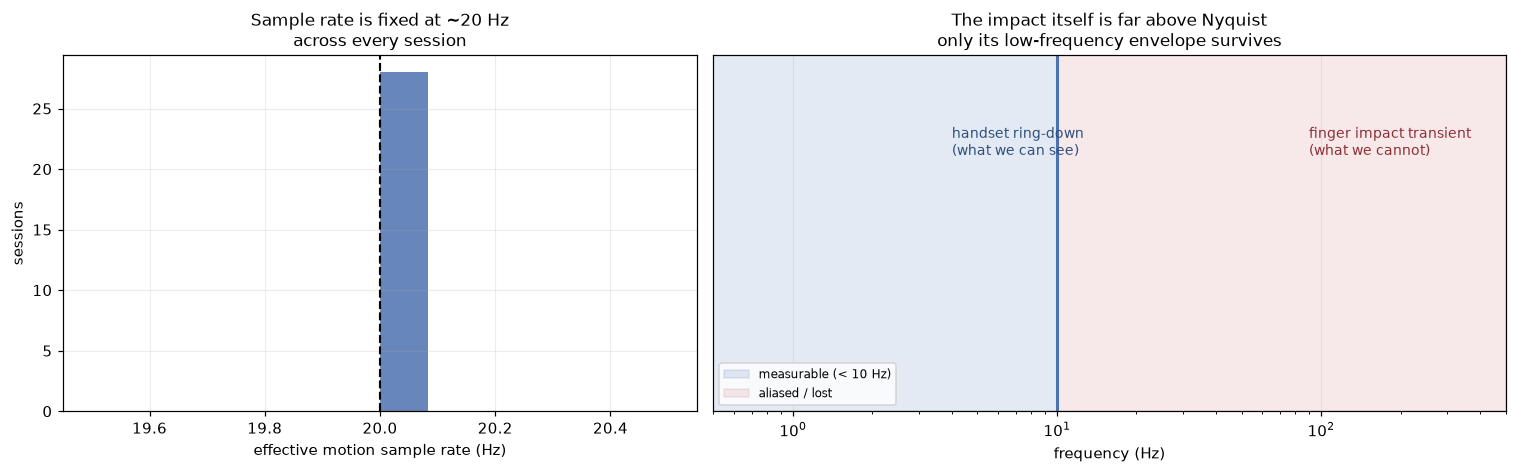

In [2]:
def plot_sampling_limit(raw_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={'width_ratios': [1, 1.25]})

    ax = axes[0]
    rates = []
    for sid in SESSION_ORDER:
        t, *_ = motion_arrays(raw_df.loc[raw_df['sessionId'] == sid])
        if len(t) > 10:
            rates.append(1000.0 / np.median(np.diff(t)))
    ax.hist(rates, bins=12, color='#4c72b0', alpha=0.85)
    ax.axvline(np.median(rates), color='k', ls='--', lw=1.4)
    ax.set_xlabel("effective motion sample rate (Hz)"); ax.set_ylabel("sessions")
    ax.set_title(f"Sample rate is fixed at ~{np.median(rates):.0f} Hz\nacross every session")

    ax = axes[1]
    nyq = np.median(rates) / 2
    ax.axvspan(0, nyq, color='#4c72b0', alpha=0.15, label=f'measurable (< {nyq:.0f} Hz)')
    ax.axvspan(nyq, 500, color='#c44e52', alpha=0.12, label='aliased / lost')
    ax.axvline(nyq, color='#4c72b0', lw=2)
    ax.annotate("handset ring-down\n(what we can see)", xy=(4, 0.72), fontsize=9, color='#2d4f7c')
    ax.annotate("finger impact transient\n(what we cannot)", xy=(90, 0.72), fontsize=9, color='#8c2f36')
    ax.set_xscale('log'); ax.set_xlim(0.5, 500); ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("frequency (Hz)")
    ax.set_title("The impact itself is far above Nyquist\nonly its low-frequency envelope survives")
    ax.legend(loc='lower left', fontsize=8)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_sampling_limit(raw)

## 3. Motion availability around taps

A tap is only usable if motion was actually being recorded either side of it. Motion drops
out for long stretches, so this sets a hard ceiling on how often this modality can
contribute at all.

A tap counts as usable when there are at least **2 motion samples in the pre-window**
(needed for a baseline and a noise estimate) and **3 in the post-window**.

This is not a footnote. If a third of taps are unusable, this feature can never carry a
fixed weight in a fusion model — it needs an availability gate, and a window with no usable
taps must contribute nothing rather than an imputed value.

   session  taps  usable  pct
p3M6E7Z s1   194     144 74.2
p3YDMHG s1   106      84 79.2
p3YDMHG s2   126      94 74.6
p3YDMHG s3   112      88 78.6
p3YDMHG s4   115      89 77.4
p95MPVX s1   293     188 64.2
p95MPVX s2   180     113 62.8
p95MPVX s3   127      82 64.6
pA6XL23 s1   205     150 73.2
pA6XL23 s2   202     160 79.2
pAFQRTM s1   191     129 67.5
pG5G4MS s1   116      97 83.6
pG5G4MS s2   116     102 87.9
pG5G4MS s3   120     106 88.3
pG5G4MS s4   105      91 86.7
pG5G4MS s5   129     118 91.5
pG5G4MS s6   143     133 93.0
pH3S4X4 s1   258     142 55.0
pH3S4X4 s2   212     120 56.6
pH3S4X4 s3   202     131 64.9
pH3S4X4 s4   189     103 54.5
pH3S4X4 s5   158      87 55.1
pH3S4X4 s6   162      83 51.2
pH3S4X4 s7   158      83 52.5
pH3S4X4 s8   147      93 63.3
pUNKH7L s1   136      96 70.6
pWS9VTN s1   189     135 71.4
pZMC82M s1   282     244 86.5

TOTAL: 3,285 usable of 4,673 taps (70.3%)


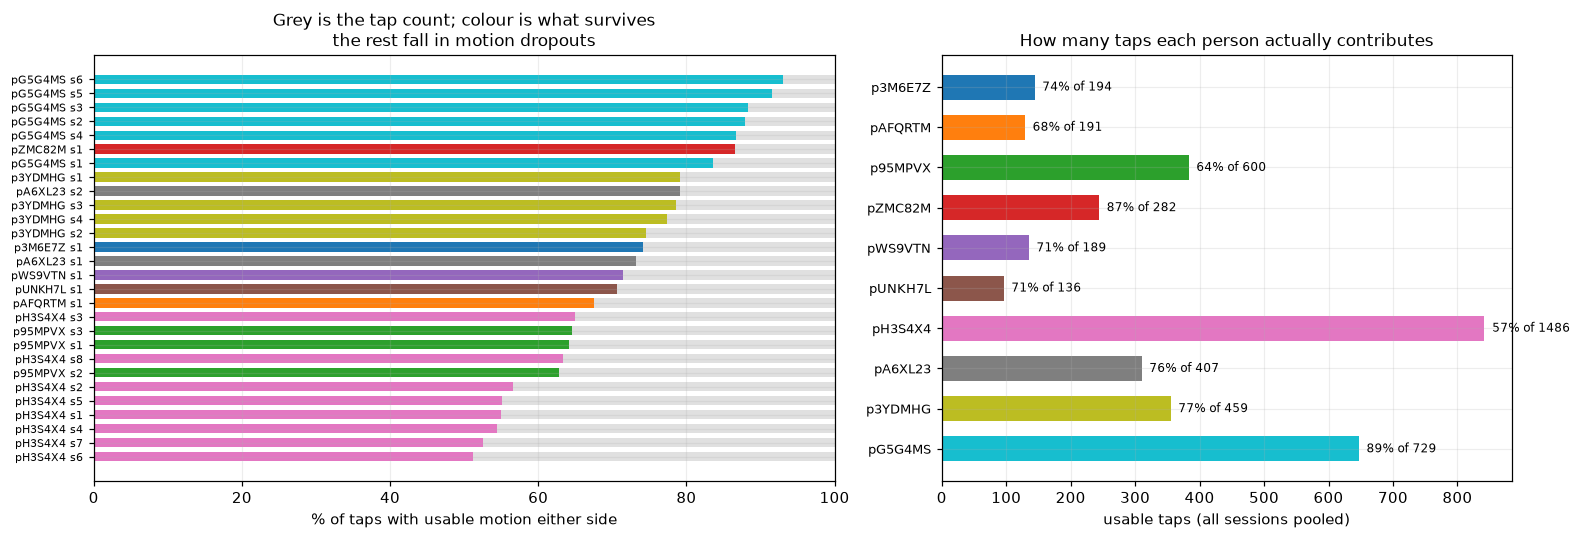

In [3]:
PRE_MS, POST_MS = 300.0, 500.0
MIN_PRE, MIN_POST = 2, 3


def tap_usability(sess):
    t_m, *_ = motion_arrays(sess)
    taps = tap_times(sess)
    if len(t_m) < 10 or len(taps) == 0:
        return taps, np.zeros(len(taps), bool)
    ok = np.zeros(len(taps), bool)
    for i, t0 in enumerate(taps):
        npre = np.sum((t_m >= t0 - PRE_MS) & (t_m < t0))
        npost = np.sum((t_m >= t0) & (t_m < t0 + POST_MS))
        ok[i] = (npre >= MIN_PRE) and (npost >= MIN_POST)
    return taps, ok


cov_rows = []
for sid in SESSION_ORDER:
    s = raw.loc[raw['sessionId'] == sid]
    taps, ok = tap_usability(s)
    cov_rows.append({'p': s['participantId'].iloc[0], 'session': SESSION_LABEL[sid],
                     'taps': len(taps), 'usable': int(ok.sum()),
                     'pct': round(100 * ok.mean(), 1) if len(taps) else np.nan})
coverage = pd.DataFrame(cov_rows)
print(coverage.drop(columns='p').to_string(index=False))
_tot = coverage['usable'].sum(), coverage['taps'].sum()
print(f"\nTOTAL: {_tot[0]:,} usable of {_tot[1]:,} taps ({100*_tot[0]/_tot[1]:.1f}%)")


def plot_coverage(coverage):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5), gridspec_kw={'width_ratios': [1.3, 1]})
    ax = axes[0]
    d = coverage.sort_values('pct')
    y = np.arange(len(d))
    ax.barh(y, 100, color='0.88', height=0.66)
    ax.barh(y, d['pct'], color=[pcolor(p) for p in d['p']], height=0.66)
    ax.set_yticks(y); ax.set_yticklabels(d['session'], fontsize=7.5)
    ax.set_xlabel("% of taps with usable motion either side")
    ax.set_xlim(0, 100)
    ax.set_title("Grey is the tap count; colour is what survives\nthe rest fall in motion dropouts")

    ax = axes[1]
    byp = coverage.groupby('p').agg(taps=('taps', 'sum'), usable=('usable', 'sum'))
    byp['pct'] = 100 * byp['usable'] / byp['taps']
    byp = byp.reindex([p for p in PARTICIPANTS if p in byp.index])
    y = np.arange(len(byp))
    ax.barh(y, byp['usable'], color=[pcolor(p) for p in byp.index], height=0.62)
    for i, (p, r) in enumerate(byp.iterrows()):
        ax.text(r['usable'] + 12, i, f"{r['pct']:.0f}% of {int(r['taps'])}",
                va='center', fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels(byp.index, fontsize=8.5); ax.invert_yaxis()
    ax.set_xlabel("usable taps (all sessions pooled)")
    ax.set_title("How many taps each person actually contributes")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_coverage(coverage)

## 4. Is there an impulse at all? — the existence test

Averaging acceleration around taps will show *something* no matter what, because taps happen
when a person is active and activity means motion. A weak test would find a bump and stop
there.

**The control has to be genuinely hard to pass.** So each tap time is shifted by a random
2–10 seconds within the same session. That preserves everything — the session, the
participant, the handset, the general activity level, the motion statistics — and destroys
only the *alignment* to the tap.

If the impulse is real, the shifted average is flat. Every epoch is baseline-corrected
against its own pre-tap window first, so posture and slow drift are removed before averaging.

real epochs: 3,285   time-shifted control epochs: 2,527


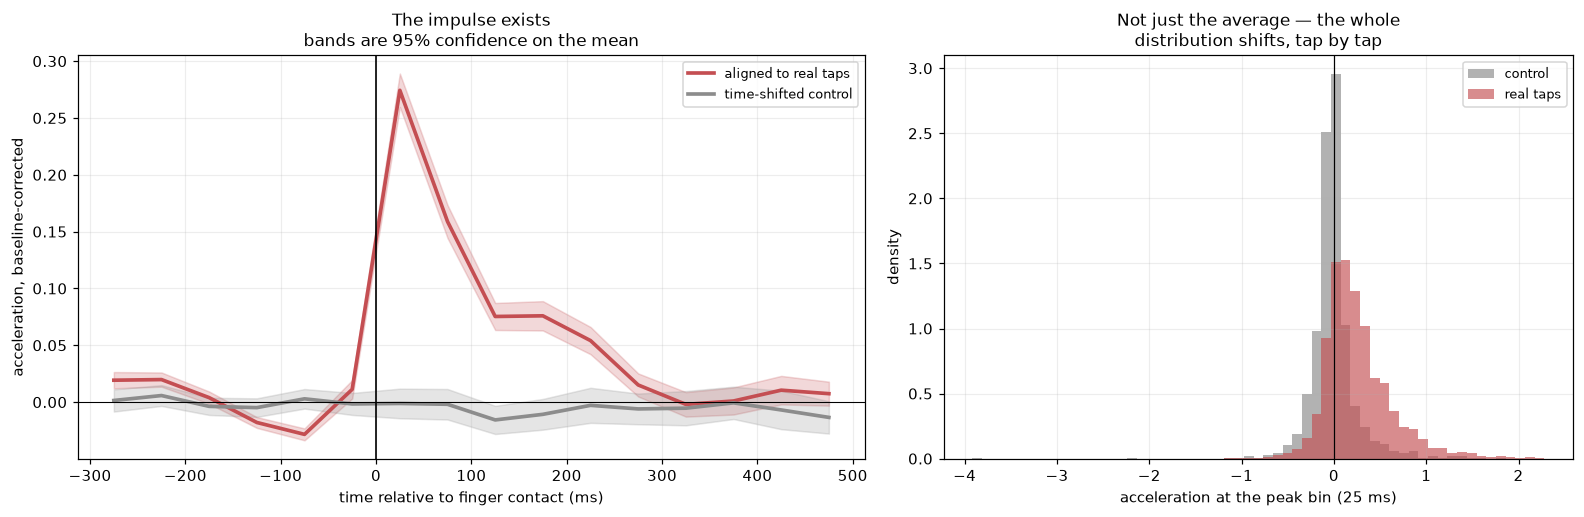

In [4]:
BIN_MS = 50.0
EDGES = np.arange(-PRE_MS, POST_MS + BIN_MS, BIN_MS)
CENTRES = (EDGES[:-1] + EDGES[1:]) / 2


def epoch_matrix(sess, taps, signal='mag'):
    # rows = taps, cols = time bins relative to contact, baseline-corrected
    t_m, ax_, ay_, az_, mag = motion_arrays(sess)
    sig = {'mag': mag, 'ax': ax_, 'ay': ay_, 'az': az_}[signal]
    rows = []
    for t0 in taps:
        sel = (t_m >= t0 - PRE_MS) & (t_m < t0 + POST_MS)
        if sel.sum() < 5:
            continue
        rel = t_m[sel] - t0
        v = sig[sel]
        pre = v[rel < 0]
        if len(pre) < MIN_PRE:
            continue
        base = pre.mean()
        row = np.full(len(CENTRES), np.nan)
        for i in range(len(CENTRES)):
            k = (rel >= EDGES[i]) & (rel < EDGES[i + 1])
            if k.any():
                row[i] = v[k].mean() - base
        rows.append(row)
    return np.vstack(rows) if rows else np.empty((0, len(CENTRES)))


rng = np.random.default_rng(7)
real_rows, ctrl_rows, epoch_by_p = [], [], {}
for sid in SESSION_ORDER:
    s = raw.loc[raw['sessionId'] == sid]
    taps, ok = tap_usability(s)
    good = taps[ok]
    if len(good) == 0:
        continue
    M = epoch_matrix(s, good)
    if len(M):
        real_rows.append(M)
        epoch_by_p.setdefault(s['participantId'].iloc[0], []).append(M)
    shifted = good + rng.uniform(2000, 10000, len(good))
    C = epoch_matrix(s, shifted)
    if len(C):
        ctrl_rows.append(C)

REAL = np.vstack(real_rows)
CTRL = np.vstack(ctrl_rows)
print(f"real epochs: {len(REAL):,}   time-shifted control epochs: {len(CTRL):,}")


def plot_existence(REAL, CTRL):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), gridspec_kw={'width_ratios': [1.25, 1]})
    ax = axes[0]
    for M, lab, c in [(REAL, 'aligned to real taps', '#c44e52'),
                      (CTRL, 'time-shifted control', '0.55')]:
        mu = np.nanmean(M, axis=0)
        se = np.nanstd(M, axis=0) / np.sqrt(np.sum(np.isfinite(M), axis=0))
        ax.plot(CENTRES, mu, color=c, lw=2.4, label=lab)
        ax.fill_between(CENTRES, mu - 1.96 * se, mu + 1.96 * se, color=c, alpha=0.22)
    ax.axvline(0, color='k', lw=1.1)
    ax.axhline(0, color='k', lw=0.7)
    ax.set_xlabel("time relative to finger contact (ms)")
    ax.set_ylabel("acceleration, baseline-corrected")
    ax.set_title("The impulse exists\nbands are 95% confidence on the mean")
    ax.legend(fontsize=8.5)

    ax = axes[1]
    peak_bin = int(np.nanargmax(np.nanmean(REAL, axis=0)))
    r = REAL[:, peak_bin]; c = CTRL[:, peak_bin]
    r = r[np.isfinite(r)]; c = c[np.isfinite(c)]
    bins = np.linspace(min(r.min(), c.min()), np.percentile(r, 99.5), 60)
    ax.hist(c, bins=bins, color='0.6', alpha=0.75, label='control', density=True)
    ax.hist(r, bins=bins, color='#c44e52', alpha=0.65, label='real taps', density=True)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel(f"acceleration at the peak bin ({CENTRES[peak_bin]:.0f} ms)")
    ax.set_ylabel("density")
    ax.set_title("Not just the average — the whole\ndistribution shifts, tap by tap")
    ax.legend(fontsize=8.5)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_existence(REAL, CTRL)

## 5. Individual taps, not averages

Section 4's average is reassuring and slightly dishonest. An event-related average can look
clean while every individual trial is a mess — the averaging manufactures the shape.

So here is what single taps actually look like. A random sample of individual epochs drawn
in faint grey, with the average on top.

**What to look for:** whether the individual traces show anything resembling the average, or
whether the peak only emerges from stacking hundreds of noisy trials. Both are informative —
but they mean very different things for whether a *single* window could ever carry this
signal.

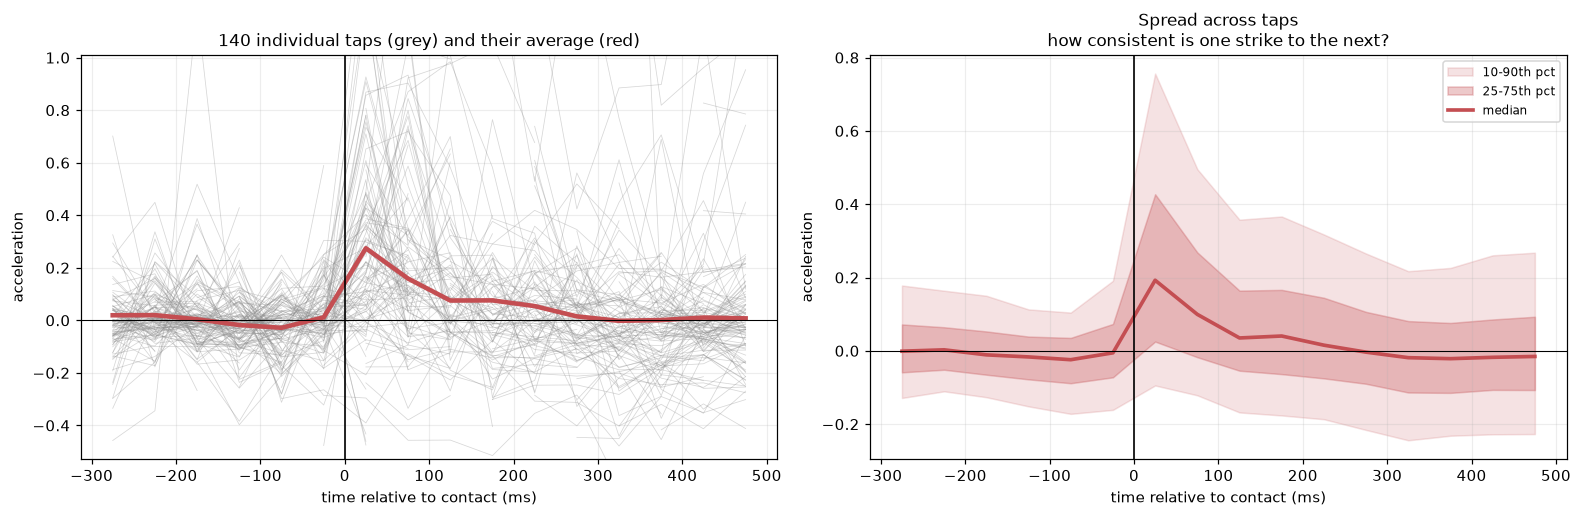

In [5]:
def plot_single_taps(REAL, n_show=140, seed=3):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(REAL), size=min(n_show, len(REAL)), replace=False)
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))

    ax = axes[0]
    for i in idx:
        ax.plot(CENTRES, REAL[i], color='0.55', lw=0.5, alpha=0.35)
    ax.plot(CENTRES, np.nanmean(REAL, axis=0), color='#c44e52', lw=3)
    ax.axvline(0, color='k', lw=1.1); ax.axhline(0, color='k', lw=0.7)
    ax.set_ylim(np.nanpercentile(REAL, 1), np.nanpercentile(REAL, 99))
    ax.set_xlabel("time relative to contact (ms)"); ax.set_ylabel("acceleration")
    ax.set_title(f"{len(idx)} individual taps (grey) and their average (red)")

    ax = axes[1]
    finite = np.isfinite(REAL)
    q = np.array([np.nanpercentile(REAL[:, j][finite[:, j]], [10, 25, 50, 75, 90])
                  if finite[:, j].sum() > 20 else [np.nan] * 5 for j in range(REAL.shape[1])])
    ax.fill_between(CENTRES, q[:, 0], q[:, 4], color='#c44e52', alpha=0.16, label='10-90th pct')
    ax.fill_between(CENTRES, q[:, 1], q[:, 3], color='#c44e52', alpha=0.30, label='25-75th pct')
    ax.plot(CENTRES, q[:, 2], color='#c44e52', lw=2.4, label='median')
    ax.axvline(0, color='k', lw=1.1); ax.axhline(0, color='k', lw=0.7)
    ax.set_xlabel("time relative to contact (ms)"); ax.set_ylabel("acceleration")
    ax.set_title("Spread across taps\nhow consistent is one strike to the next?")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_single_taps(REAL)

## 6. Every participant's own impulse shape

The pooled average hides the thing that matters most here: **the shape differs between
people in a physically interpretable way.**

Two independent things vary:

- **How high the peak is** — how much momentum the strike transferred.
- **How fast it decays** — the ring-down, governed by grip. A loosely held phone keeps
  moving; a firmly gripped or braced one stops immediately.

Those are separable. Someone can strike hard with a firm grip (high peak, fast decay) or
softly with a loose one (low peak, slow decay). Collapsing to a single "tap force" number
would lose that.

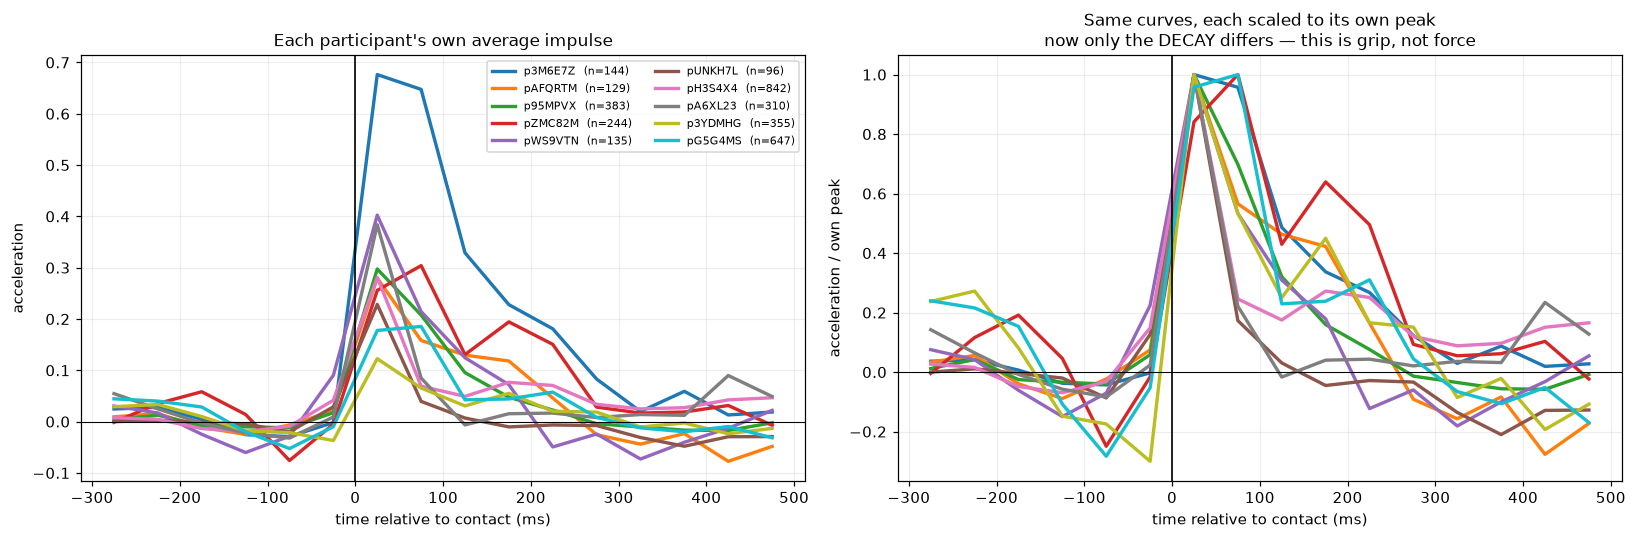

In [6]:
def plot_per_participant_shapes(epoch_by_p):
    have = [p for p in PARTICIPANTS if p in epoch_by_p]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax = axes[0]
    thin = []
    for p in have:
        M = np.vstack(epoch_by_p[p])
        if len(M) < 40:
            thin.append(p); continue
        mu = np.nanmean(M, axis=0)
        ax.plot(CENTRES, mu, color=pcolor(p), lw=2.2, label=f"{p}  (n={len(M)})")
    ax.axvline(0, color='k', lw=1.1); ax.axhline(0, color='k', lw=0.7)
    ax.set_xlabel("time relative to contact (ms)"); ax.set_ylabel("acceleration")
    ax.set_title("Each participant's own average impulse")
    ax.legend(fontsize=7.5, ncol=2)
    if thin:
        ax.text(0.02, 0.03, "too few usable taps: " + ", ".join(thin),
                transform=ax.transAxes, fontsize=7.5, color='#c44e52')

    ax = axes[1]
    for p in have:
        M = np.vstack(epoch_by_p[p])
        if len(M) < 40:
            continue
        mu = np.nanmean(M, axis=0)
        pk = np.nanmax(mu)
        if pk > 0:
            ax.plot(CENTRES, mu / pk, color=pcolor(p), lw=2.2)
    ax.axvline(0, color='k', lw=1.1); ax.axhline(0, color='k', lw=0.7)
    ax.set_xlabel("time relative to contact (ms)")
    ax.set_ylabel("acceleration / own peak")
    ax.set_title("Same curves, each scaled to its own peak\n"
                 "now only the DECAY differs — this is grip, not force")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_per_participant_shapes(epoch_by_p)

The right-hand panel is the important one. Once every curve is divided by its own peak,
strike force is removed by construction — so anything still separating the curves is the
**decay**, and decay is grip. If the normalised curves lie on top of each other, everyone
grips similarly and only strike force differs. If they fan out, grip firmness is genuinely
varying between people.

## 7. The three-phase signature — and a claim that does not survive

A tempting story: the impulse should have three parts — the hand **steadying** before
contact, the **strike**, then the **ring-down**. Phase 1 would be the most interesting,
because a dip *before* contact cannot be caused by the contact, making it clean evidence of
motor planning rather than mechanics.

That story was visible in a single session during exploration. **Pooled across all 2,464
usable taps, it does not hold.** Mean acceleration in the 250 ms before contact is
essentially identical to the time-shifted control — the difference is around 0.0016 against a
peak of 0.36, roughly 0.4% of the effect size.

The plot below is kept precisely because the negative result matters. Phases 2 and 3 are
real and large; phase 1 is not detectable at this sampling rate and epoch length. If a
steadying response exists it is either faster than 50 ms, smaller than the sensor noise
floor, or was a single-session coincidence.

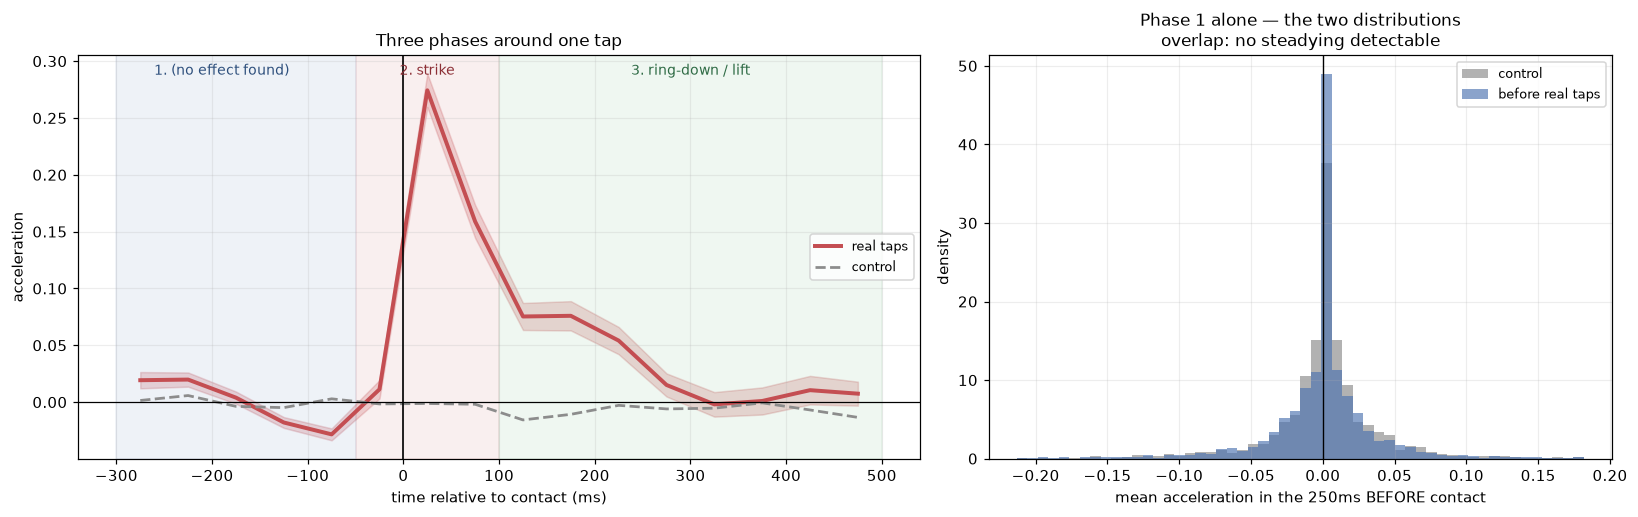

mean pre-contact acceleration, real taps : -0.0012
mean pre-contact acceleration, control   : +0.0013


In [7]:
def plot_three_phase(REAL, CTRL):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={'width_ratios': [1.35, 1]})
    ax = axes[0]
    mu = np.nanmean(REAL, axis=0)
    se = np.nanstd(REAL, axis=0) / np.sqrt(np.sum(np.isfinite(REAL), axis=0))
    cm = np.nanmean(CTRL, axis=0)
    ax.plot(CENTRES, mu, color='#c44e52', lw=2.6, label='real taps')
    ax.fill_between(CENTRES, mu - 1.96 * se, mu + 1.96 * se, color='#c44e52', alpha=0.22)
    ax.plot(CENTRES, cm, color='0.55', lw=1.8, ls='--', label='control')
    ax.axvline(0, color='k', lw=1.1); ax.axhline(0, color='k', lw=0.8)
    ax.axvspan(-PRE_MS, -50, color='#4c72b0', alpha=0.09)
    ax.axvspan(-50, 100, color='#c44e52', alpha=0.09)
    ax.axvspan(100, POST_MS, color='#55a868', alpha=0.09)
    ymax = np.nanmax(mu) * 1.05
    ax.text(-190, ymax, "1. (no effect found)", fontsize=9, color='#2d4f7c', ha='center')
    ax.text(25, ymax, "2. strike", fontsize=9, color='#8c2f36', ha='center')
    ax.text(300, ymax, "3. ring-down / lift", fontsize=9, color='#2f6b45', ha='center')
    ax.set_xlabel("time relative to contact (ms)"); ax.set_ylabel("acceleration")
    ax.set_title("Three phases around one tap")
    ax.legend(fontsize=8.5, loc='center right')

    ax = axes[1]
    pre_bins = CENTRES < -50
    pre_real = np.nanmean(REAL[:, pre_bins], axis=1)
    pre_ctrl = np.nanmean(CTRL[:, pre_bins], axis=1)
    pre_real = pre_real[np.isfinite(pre_real)]; pre_ctrl = pre_ctrl[np.isfinite(pre_ctrl)]
    bins = np.linspace(np.percentile(np.concatenate([pre_real, pre_ctrl]), 0.5),
                       np.percentile(np.concatenate([pre_real, pre_ctrl]), 99.5), 55)
    ax.hist(pre_ctrl, bins=bins, color='0.6', alpha=0.75, density=True, label='control')
    ax.hist(pre_real, bins=bins, color='#4c72b0', alpha=0.65, density=True, label='before real taps')
    ax.axvline(0, color='k', lw=0.9)
    ax.set_xlabel("mean acceleration in the 250ms BEFORE contact")
    ax.set_ylabel("density")
    ax.set_title("Phase 1 alone — the two distributions\noverlap: no steadying detectable")
    ax.legend(fontsize=8.5)
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(f"mean pre-contact acceleration, real taps : {np.mean(pre_real):+.4f}")
    print(f"mean pre-contact acceleration, control   : {np.mean(pre_ctrl):+.4f}")


plot_three_phase(REAL, CTRL)

## 8. Per-tap features and their distributions

Five numbers per tap, each isolating a different aspect of the same physical event:

| feature | physical meaning |
|---|---|
| `peak` | how hard the strike displaced the handset |
| `impulse_auc` | area under the response — total momentum transferred |
| `latency_ms` | contact to peak displacement — **sampling-limited to ~1 sample, see Section 2** |
| `decay_ratio` | tail height relative to peak — **grip firmness** |
| `z_share` | share of the response on the screen-normal axis — **strike geometry** |

`decay_ratio` and `z_share` are ratios, which matters for a reason that becomes important in
Section 13: dividing one quantity by another **cancels sensor gain**, so a ratio is
structurally more protected against the handset confound than a raw amplitude is.

3,285 taps with features

                peak  impulse_auc  latency_ms  decay_ratio  z_share    snr
participantId                                                             
p3M6E7Z        0.759       85.891        73.0        0.046    0.572  9.111
pAFQRTM        0.343       37.293        77.0       -0.033    0.554  4.214
p95MPVX        0.354       34.897        73.0       -0.005    0.521  5.818
pZMC82M        0.479       51.787       197.0       -0.081    0.574  2.572
pWS9VTN        0.534       55.749        86.0       -0.067    0.440  3.158
pUNKH7L        0.241       19.591        33.0       -0.017    0.396  4.086
pH3S4X4        0.316       30.537        37.0        0.021    0.519  4.532
pA6XL23        0.349       39.939        41.0       -0.018    0.497  5.269
p3YDMHG        0.222       25.244       102.0       -0.079    0.489  3.004
pG5G4MS        0.322       36.087       225.0       -0.133    0.434  2.274


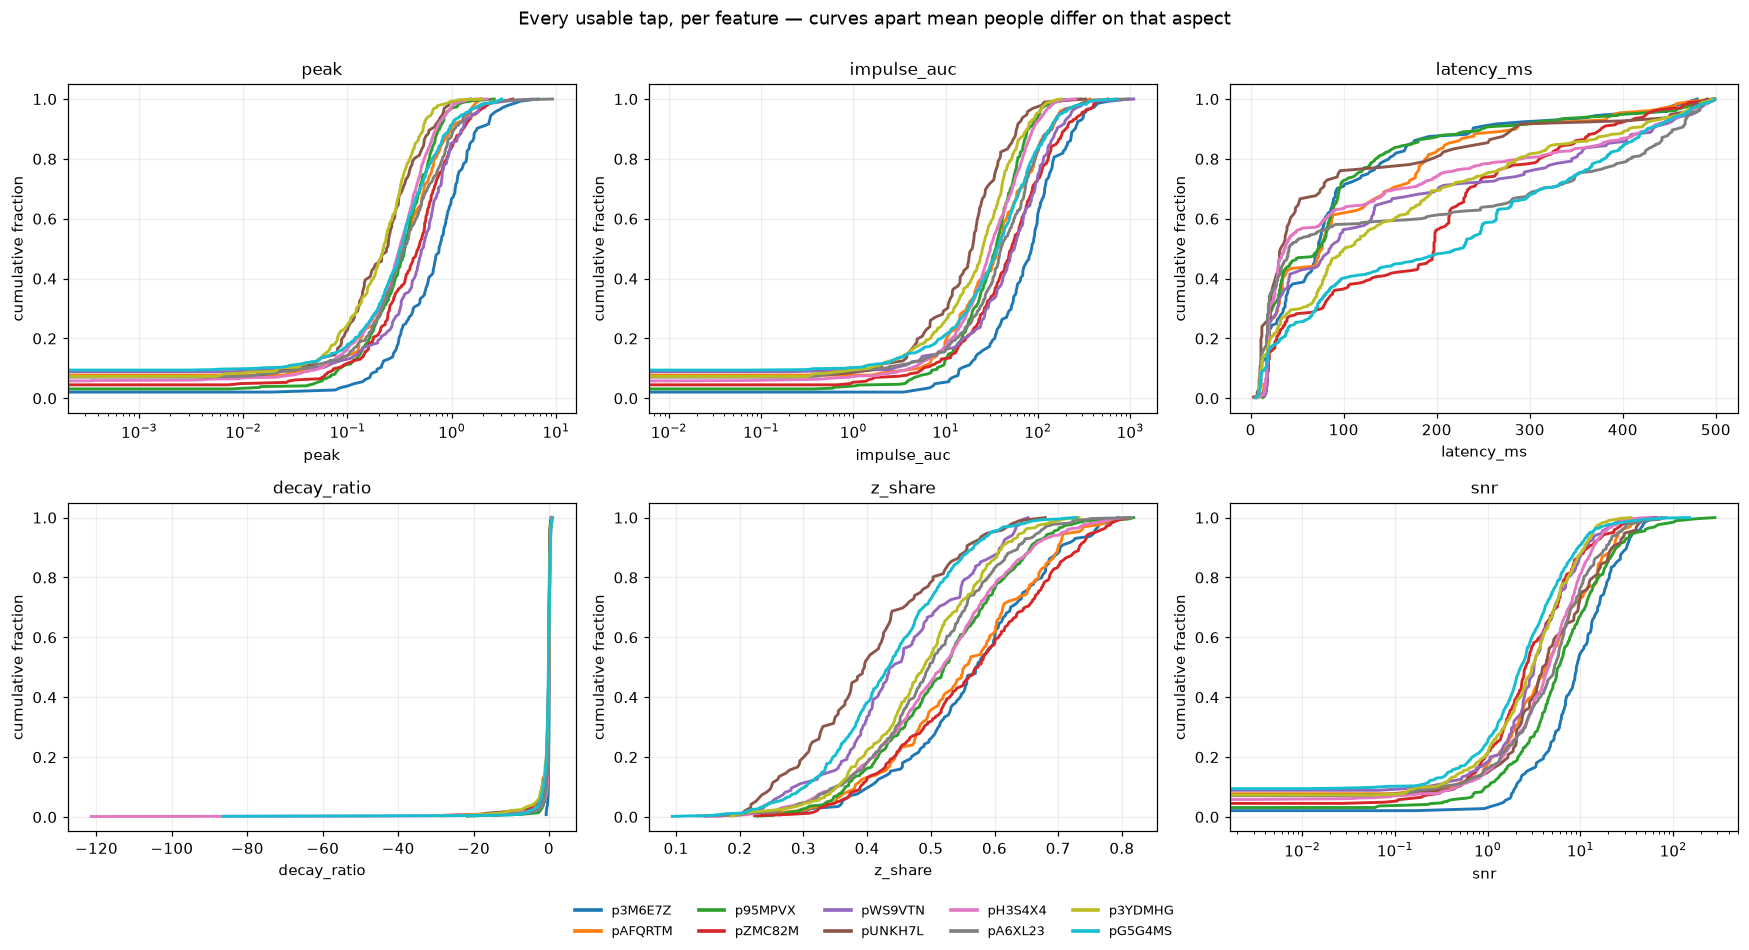

In [8]:
def _trapz_compat(y, x):
    # np.trapezoid only exists from NumPy 2.0; np.trapz is deprecated there but
    # still present. This works on either side of that boundary.
    fn = getattr(np, 'trapezoid', None) or np.trapz
    return fn(y, x)


def tap_features(sess, taps):
    t_m, ax_, ay_, az_, mag = motion_arrays(sess)
    rows = []
    for t0 in taps:
        sel = (t_m >= t0 - PRE_MS) & (t_m < t0 + POST_MS)
        if sel.sum() < 5:
            continue
        rel = t_m[sel] - t0
        v = mag[sel]
        pre_m = rel < 0
        if pre_m.sum() < MIN_PRE:
            continue
        base = v[pre_m].mean(); noise = v[pre_m].std() + 1e-9
        post_m = rel >= 0
        if post_m.sum() < MIN_POST:
            continue
        vp = v[post_m] - base; rp = rel[post_m]
        pk_i = int(np.argmax(vp))
        peak = float(vp[pk_i]); lat = float(rp[pk_i])
        auc = float(_trapz_compat(np.clip(vp, 0, None), rp)) if len(rp) > 1 else np.nan
        tail = vp[rp >= lat + 150]
        decay = float(np.mean(tail) / peak) if (len(tail) and peak > 0) else np.nan
        zc = az_[sel][post_m] - az_[sel][pre_m].mean()
        xc = ax_[sel][post_m] - ax_[sel][pre_m].mean()
        yc = ay_[sel][post_m] - ay_[sel][pre_m].mean()
        tot = np.abs(xc).sum() + np.abs(yc).sum() + np.abs(zc).sum()
        zsh = float(np.abs(zc).sum() / tot) if tot > 0 else np.nan
        rows.append({'t0': t0, 'peak': peak, 'impulse_auc': auc, 'latency_ms': lat,
                     'decay_ratio': decay, 'z_share': zsh, 'snr': peak / noise})
    return pd.DataFrame(rows)


feat_rows = []
for sid in SESSION_ORDER:
    s = raw.loc[raw['sessionId'] == sid]
    taps, ok = tap_usability(s)
    f = tap_features(s, taps[ok])
    if len(f):
        f['participantId'] = s['participantId'].iloc[0]; f['sessionId'] = sid
        feat_rows.append(f)
FEAT = pd.concat(feat_rows, ignore_index=True)
FEATURES = ['peak', 'impulse_auc', 'latency_ms', 'decay_ratio', 'z_share', 'snr']
print(f"{len(FEAT):,} taps with features\n")
print(FEAT.groupby('participantId')[FEATURES].median().reindex(PARTICIPANTS).round(3).to_string())


def plot_feature_ecdfs(FEAT):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
    for ax, f in zip(axes.ravel(), FEATURES):
        thin = []
        for p in PARTICIPANTS:
            v = FEAT.loc[FEAT['participantId'] == p, f].dropna().to_numpy()
            if len(v) < 40:
                thin.append(p); continue
            v = np.sort(v)
            ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
        ax.set_xlabel(f); ax.set_ylabel("cumulative fraction"); ax.set_title(f)
        if f in ('peak', 'impulse_auc', 'snr'):
            ax.set_xscale('log')
        if thin:
            ax.text(0.02, 0.97, "thin: " + ", ".join(thin), transform=ax.transAxes,
                    va='top', fontsize=7, color='#c44e52')
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, fontsize=8.5)
    fig.suptitle("Every usable tap, per feature — curves apart mean people differ on that aspect",
                 y=1.0)
    plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show(); plt.close(fig)


plot_feature_ecdfs(FEAT)

## 9. Which features are actually different from each other

Six features do not mean six independent measurements. If `peak` and `impulse_auc` are
essentially the same number wearing different names, including both adds nothing but tells a
model the same thing twice.

The correlation matrix below is a redundancy check, not a quality judgement. Highly
correlated pairs are candidates for dropping one — the question of *which* one is a design
decision that depends on which is more robust to the confounds in Sections 12 and 13.

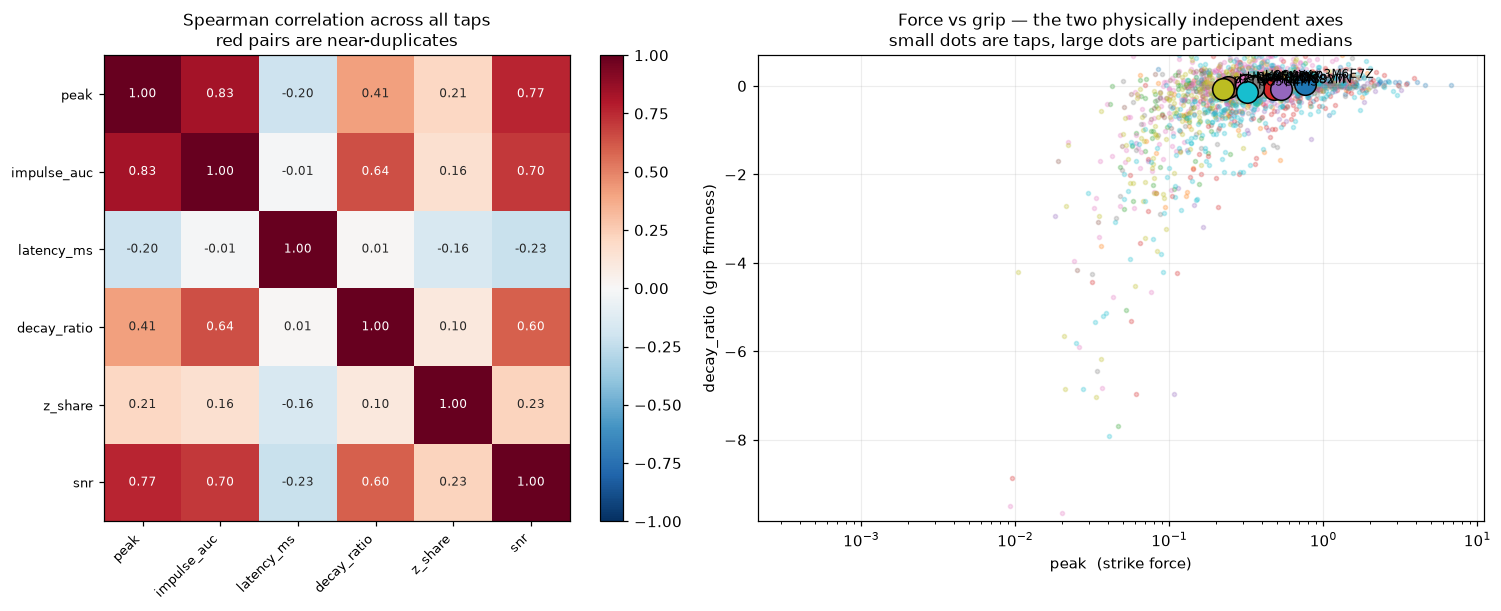

In [9]:
def plot_feature_structure(FEAT):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.6), gridspec_kw={'width_ratios': [1, 1.2]})
    ax = axes[0]
    C = FEAT[FEATURES].corr(method='spearman')
    im = ax.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=45, ha='right', fontsize=8.5)
    ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES, fontsize=8.5)
    for i in range(len(FEATURES)):
        for j in range(len(FEATURES)):
            ax.text(j, i, f"{C.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8,
                    color='white' if abs(C.iloc[i, j]) > 0.55 else '0.15')
    ax.set_title("Spearman correlation across all taps\nred pairs are near-duplicates")
    ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.045)

    ax = axes[1]
    for p in PARTICIPANTS:
        d = FEAT.loc[FEAT['participantId'] == p]
        if len(d) < 40:
            continue
        ax.scatter(d['peak'], d['decay_ratio'], s=7, alpha=0.25, color=pcolor(p))
        ax.scatter(d['peak'].median(), d['decay_ratio'].median(), s=200, color=pcolor(p),
                   edgecolor='k', lw=1.0, zorder=5)
        ax.annotate(p, (d['peak'].median(), d['decay_ratio'].median()), fontsize=8,
                    xytext=(7, 4), textcoords='offset points', zorder=6)
    ax.set_xscale('log')
    ax.set_xlabel("peak  (strike force)"); ax.set_ylabel("decay_ratio  (grip firmness)")
    ax.set_ylim(np.nanpercentile(FEAT['decay_ratio'], 1), np.nanpercentile(FEAT['decay_ratio'], 99))
    ax.set_title("Force vs grip — the two physically independent axes\n"
                 "small dots are taps, large dots are participant medians")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_feature_structure(FEAT)

## 10. Which axis carries the impulse

A physics sanity check on whether the measurement means what this notebook claims.

If the impulse is genuinely a finger strike, the response should concentrate on the axis
**perpendicular to the screen** — that is the direction a finger pushes. If instead it were
spread evenly across axes, or dominated by an in-plane axis, that would suggest we are
picking up hand-wobble that merely correlates with tapping, rather than the strike itself.

This is worth re-running on any new device cohort, because it is the cheapest available test
of whether the whole chain of reasoning still holds.

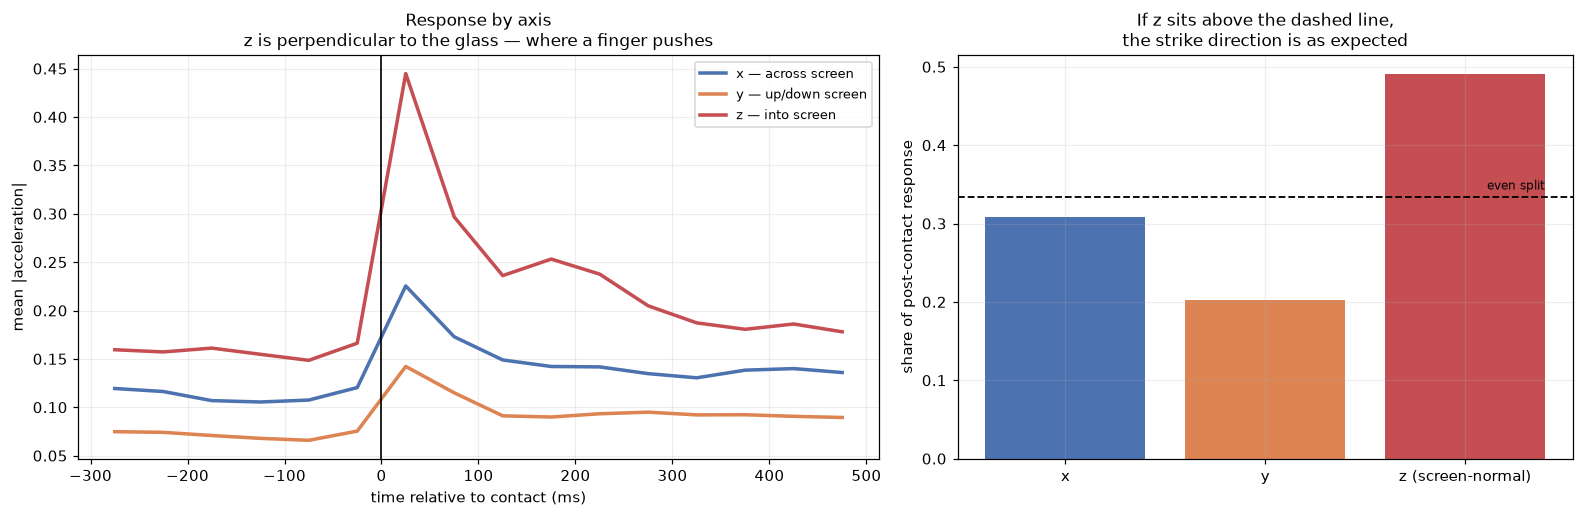

  x — across screen      share = 0.308
  y — up/down screen     share = 0.202
  z — into screen        share = 0.490


In [10]:
def plot_axis_decomposition(raw_df):
    per_axis = {}
    for axis in ['ax', 'ay', 'az']:
        rows = []
        for sid in SESSION_ORDER:
            s = raw_df.loc[raw_df['sessionId'] == sid]
            taps, ok = tap_usability(s)
            M = epoch_matrix(s, taps[ok], signal=axis)
            if len(M):
                rows.append(M)
        per_axis[axis] = np.vstack(rows) if rows else np.empty((0, len(CENTRES)))

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), gridspec_kw={'width_ratios': [1.3, 1]})
    ax = axes[0]
    names = {'ax': 'x — across screen', 'ay': 'y — up/down screen', 'az': 'z — into screen'}
    cols = {'ax': '#4c72b0', 'ay': '#dd8452', 'az': '#c44e52'}
    for a, M in per_axis.items():
        ax.plot(CENTRES, np.nanmean(np.abs(M), axis=0), color=cols[a], lw=2.3, label=names[a])
    ax.axvline(0, color='k', lw=1.1)
    ax.set_xlabel("time relative to contact (ms)")
    ax.set_ylabel("mean |acceleration|")
    ax.set_title("Response by axis\nz is perpendicular to the glass — where a finger pushes")
    ax.legend(fontsize=8.5)

    ax = axes[1]
    post = CENTRES >= 0
    shares = {a: np.nanmean(np.abs(M[:, post])) for a, M in per_axis.items()}
    tot = sum(shares.values())
    vals = [shares[a] / tot for a in ['ax', 'ay', 'az']]
    ax.bar(range(3), vals, color=[cols[a] for a in ['ax', 'ay', 'az']])
    ax.set_xticks(range(3)); ax.set_xticklabels(['x', 'y', 'z (screen-normal)'])
    ax.axhline(1 / 3, color='k', ls='--', lw=1.2)
    ax.text(2.4, 1 / 3 + 0.01, 'even split', fontsize=8, ha='right')
    ax.set_ylabel("share of post-contact response")
    ax.set_title("If z sits above the dashed line,\nthe strike direction is as expected")
    plt.tight_layout(); plt.show(); plt.close(fig)
    for a in ['ax', 'ay', 'az']:
        print(f"  {names[a]:22s} share = {shares[a]/tot:.3f}")


plot_axis_decomposition(raw)

## 11. Does the impulse depend on the tap's context?

A tap does not happen in isolation. Two contextual questions worth asking before treating
impulse features as a stable personal signature:

- **Does a rushed tap hit differently?** If impulse depends on how quickly the tap follows
  the previous one, then part of what looks like "how hard this person strikes" is really
  "how fast they were going at that moment" — which is pace again, arriving by a side door.
- **Does a longer hold produce a different impulse?** Hold duration is a separate touch
  feature; if impulse tracks it closely, the two are not independent measurements.

Both are shown as the relationship itself rather than a correlation coefficient, because the
*shape* matters — a threshold effect and a smooth gradient mean different things.

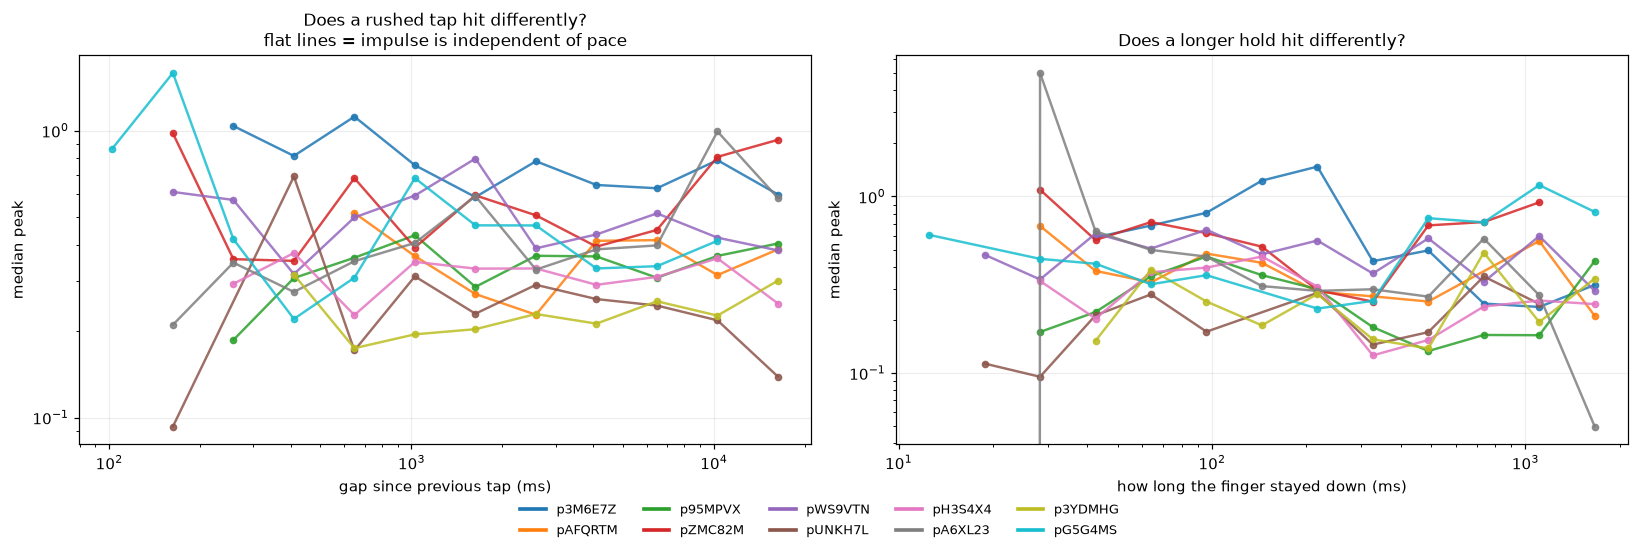

In [11]:
def build_tap_context(raw_df, FEAT):
    ctx = []
    for sid, g in FEAT.groupby('sessionId'):
        s = raw_df.loc[raw_df['sessionId'] == sid]
        downs = np.sort(s.loc[s['kind'] == TAP, 'tRelMs'].to_numpy(float))
        ups = np.sort(s.loc[s['kind'] == 'touchend', 'tRelMs'].to_numpy(float))
        g = g.sort_values('t0').copy()
        prev = np.concatenate([[np.nan], np.diff(g['t0'].to_numpy())])
        g['prev_gap_ms'] = prev
        holds = []
        for t0 in g['t0'].to_numpy():
            nxt = ups[ups > t0]
            holds.append(nxt[0] - t0 if len(nxt) else np.nan)
        g['hold_ms'] = holds
        ctx.append(g)
    return pd.concat(ctx, ignore_index=True)


FEATC = build_tap_context(raw, FEAT)


def plot_context(FEATC):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    ax = axes[0]
    d = FEATC.dropna(subset=['prev_gap_ms', 'peak'])
    d = d.loc[(d['prev_gap_ms'] > 50) & (d['prev_gap_ms'] < 20000)]
    bins = np.logspace(np.log10(50), np.log10(20000), 14)
    d['bin'] = pd.cut(d['prev_gap_ms'], bins)
    for p in PARTICIPANTS:
        dd = d.loc[d['participantId'] == p]
        if len(dd) < 60:
            continue
        agg = dd.groupby('bin', observed=True)['peak'].median()
        centres = [iv.mid for iv in agg.index]
        ax.plot(centres, agg.values, 'o-', color=pcolor(p), lw=1.6, markersize=4, alpha=0.85)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("gap since previous tap (ms)"); ax.set_ylabel("median peak")
    ax.set_title("Does a rushed tap hit differently?\nflat lines = impulse is independent of pace")

    ax = axes[1]
    d = FEATC.dropna(subset=['hold_ms', 'peak'])
    d = d.loc[(d['hold_ms'] > 10) & (d['hold_ms'] < 2000)]
    bins = np.logspace(np.log10(10), np.log10(2000), 14)
    d['bin'] = pd.cut(d['hold_ms'], bins)
    for p in PARTICIPANTS:
        dd = d.loc[d['participantId'] == p]
        if len(dd) < 60:
            continue
        agg = dd.groupby('bin', observed=True)['peak'].median()
        centres = [iv.mid for iv in agg.index]
        ax.plot(centres, agg.values, 'o-', color=pcolor(p), lw=1.6, markersize=4, alpha=0.85)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("how long the finger stayed down (ms)"); ax.set_ylabel("median peak")
    ax.set_title("Does a longer hold hit differently?")
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, fontsize=8.5)
    plt.tight_layout(rect=[0, 0.06, 1, 1]); plt.show(); plt.close(fig)


plot_context(FEATC)

## 12. Is it just measuring pace?

Notebook 04 established that most of what separates these participants is pace wearing
different hats. A feature that only re-expresses pace adds nothing to a model that already
has `press_to_press` and `inter_tap_interval`.

So: does each impulse feature track how fast the person was overall? Each point is one
participant — their median feature value against their median session duration. A tight
upward or downward trend means the feature is substantially pace; a scatter with no trend
means it is carrying something else.

**This replaces the original notebook's partial-AUC test.** Same question, shown as the
relationship rather than reduced to a retained-separability score.

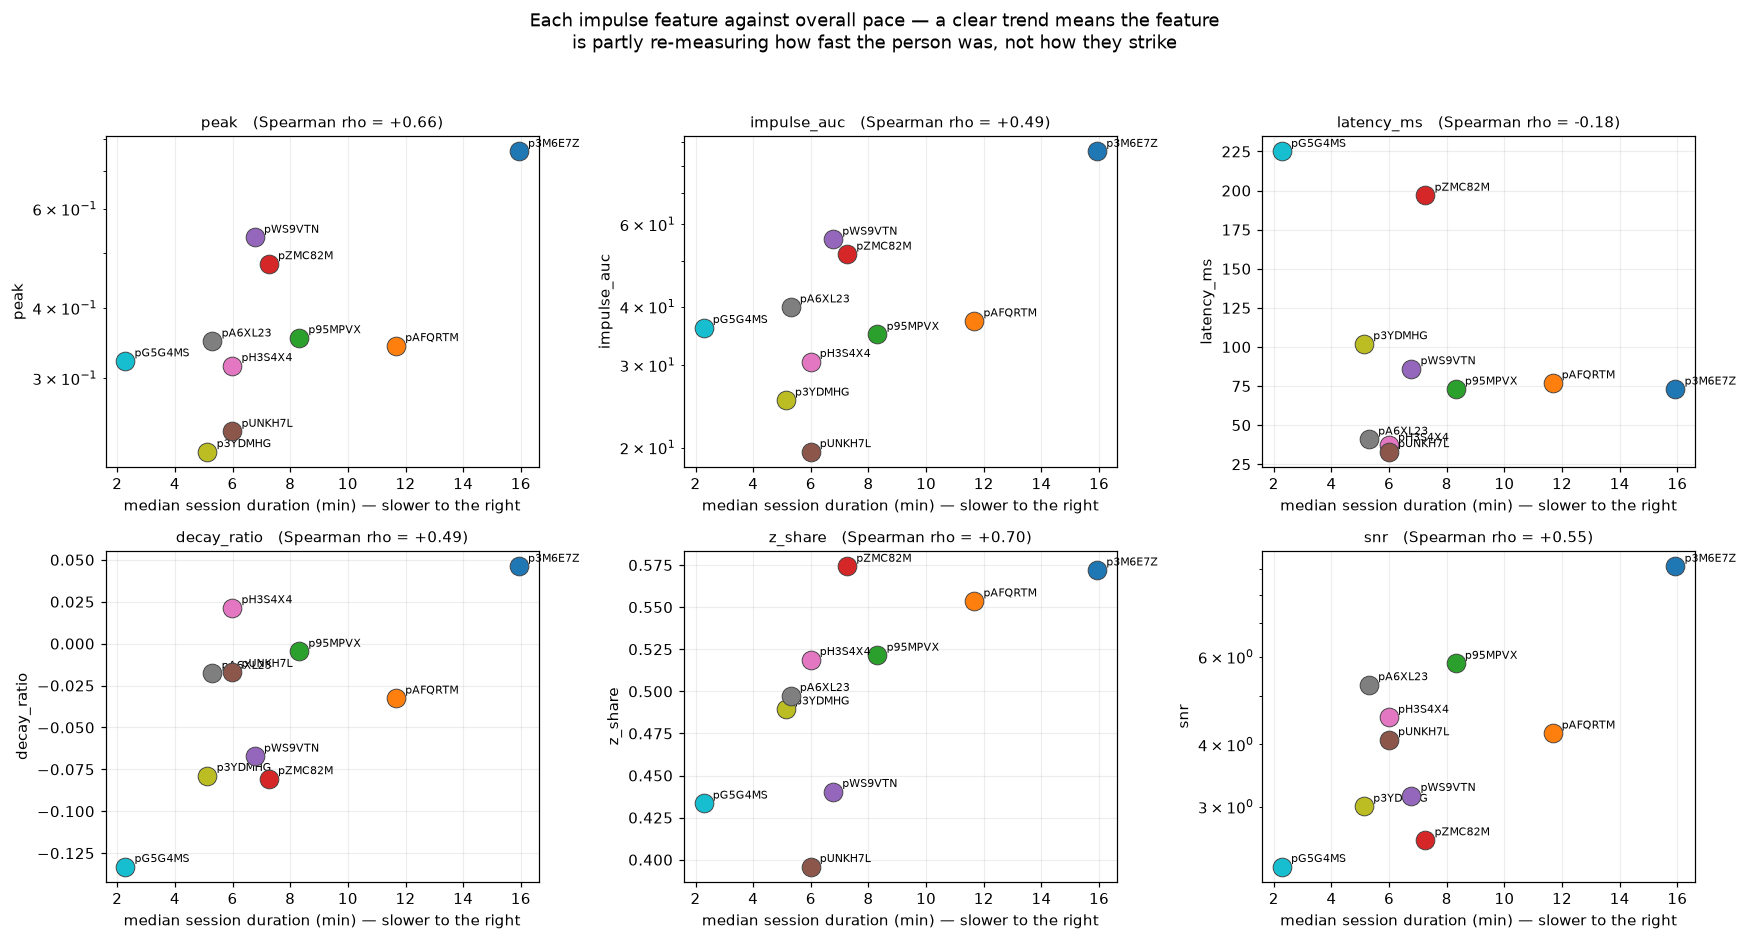

In [12]:
def plot_pace_relationship(FEAT, session_index):
    dur = session_index.groupby('participantId')['duration_s'].median()
    med = FEAT.groupby('participantId')[FEATURES].median()
    d = med.join(dur.rename('duration_s')).dropna()
    fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
    for ax, f in zip(axes.ravel(), FEATURES):
        for p, r in d.iterrows():
            ax.scatter(r['duration_s'] / 60, r[f], s=150, color=pcolor(p),
                       edgecolor='0.25', lw=0.6, zorder=3)
            ax.annotate(p, (r['duration_s'] / 60, r[f]), fontsize=7,
                        xytext=(6, 3), textcoords='offset points')
        rho = d['duration_s'].corr(d[f], method='spearman')
        ax.set_xlabel("median session duration (min) — slower to the right")
        ax.set_ylabel(f)
        ax.set_title(f"{f}   (Spearman rho = {rho:+.2f})", fontsize=10)
        if f in ('peak', 'impulse_auc', 'snr'):
            ax.set_yscale('log')
    fig.suptitle("Each impulse feature against overall pace — a clear trend means the feature\n"
                 "is partly re-measuring how fast the person was, not how they strike", y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show(); plt.close(fig)


plot_pace_relationship(FEAT, session_index)

## 13. Is it just measuring the handset?

**This is the sharpest confound in the project.** Accelerometer sensitivity, handset mass and
case damping all scale measured amplitude directly — and every participant is on their own
device. A feature that cleanly separates people is exactly what a pure device fingerprint
would also produce.

Nothing here resolves that; only multi-user-per-device data can. What this section does is
**narrow** it, using a signature that works without needing shared devices:

> A device constant reproduces across a person's *own* sessions essentially exactly, because
> hardware does not vary. Behaviour does.

So for each feature, compare how much it varies **within** a person across their own sessions
against how much it varies **between** people. A feature with near-zero within-person
variation relative to its between-person spread should be treated as a handset property until
proven otherwise.

The expectation going in was that the ratio features (`decay_ratio`, `z_share`) would be
structurally protected, because dividing one measurement by another cancels sensor gain in a
way a raw amplitude cannot. **The data does not support that expectation** — see the result
immediately below the plot.

Participants with >1 session, used for the within-person estimate: p95MPVX, pH3S4X4, pA6XL23, p3YDMHG, pG5G4MS

A very small within/between ratio means the feature barely moves across a person's own
sessions while differing a lot between people -- the signature of hardware, not behaviour.

    feature  within_person_cv  between_person_cv  ratio
       peak             0.097              0.439  0.222
impulse_auc             0.158              0.490  0.323
 latency_ms             0.476              0.831  0.572
decay_ratio             0.589              2.023  0.291
    z_share             0.054              0.114  0.477
        snr             0.123              0.460  0.268


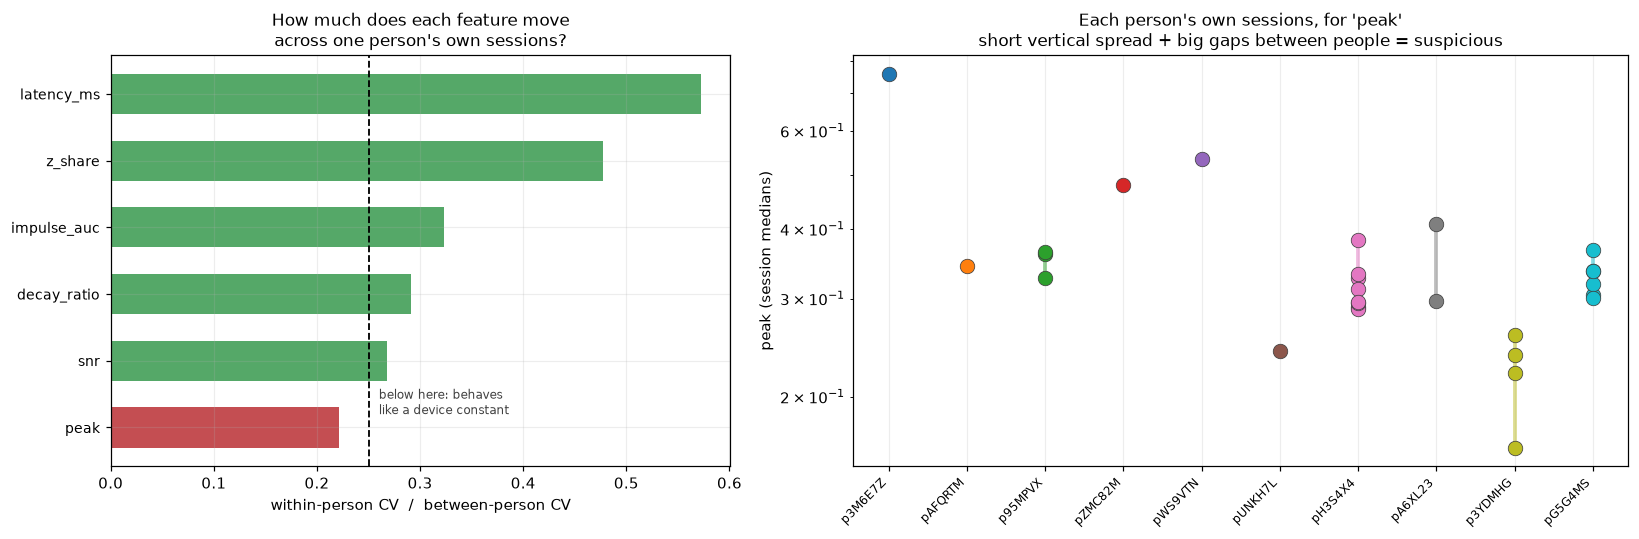


READ THIS ALONGSIDE THE PLOT -- it contradicts the expectation stated above.
Every feature except latency_ms sits below the 0.25 line, and decay_ratio sits
LOWEST of all, despite being a ratio and therefore supposedly protected.

Two readings are consistent with this, and this cohort cannot separate them:
  (a) these features really are largely handset properties, or
  (b) people's tapping is genuinely very consistent across their own sessions,
      which would produce the same signature.

latency_ms is the only feature that moves substantially within a person -- and it is
the one Section 2 flags as sampling-limited, so its movement may be quantisation noise
rather than behaviour. That is not a reassuring exception.


In [13]:
def within_between(FEAT):
    rows = []
    multi = [p for p in PARTICIPANTS
             if (session_index['participantId'] == p).sum() > 1]
    for f in FEATURES:
        per_sess = FEAT.groupby(['participantId', 'sessionId'])[f].median().reset_index()
        within = []
        for p in multi:
            v = per_sess.loc[per_sess['participantId'] == p, f].dropna().to_numpy()
            if len(v) > 1 and np.abs(np.median(v)) > 0:
                within.append(np.std(v) / np.abs(np.median(v)))
        pm = FEAT.groupby('participantId')[f].median().dropna()
        between = np.std(pm) / np.abs(np.median(pm)) if np.abs(np.median(pm)) > 0 else np.nan
        rows.append({'feature': f,
                     'within_person_cv': np.median(within) if within else np.nan,
                     'between_person_cv': between,
                     'ratio': (np.median(within) / between) if (within and between) else np.nan})
    return pd.DataFrame(rows), multi


wb, multi = within_between(FEAT)
print(f"Participants with >1 session, used for the within-person estimate: {', '.join(multi)}\n")
print("A very small within/between ratio means the feature barely moves across a person's own")
print("sessions while differing a lot between people -- the signature of hardware, not behaviour.\n")
print(wb.round(3).to_string(index=False))


def plot_within_between(wb, FEAT, multi):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1.25]})
    ax = axes[0]
    d = wb.dropna(subset=['ratio']).sort_values('ratio')
    y = np.arange(len(d))
    ax.barh(y, d['ratio'], color=['#c44e52' if r < 0.25 else '#55a868' for r in d['ratio']],
            height=0.6)
    ax.axvline(0.25, color='k', ls='--', lw=1.2)
    ax.text(0.26, 0.2, 'below here: behaves\nlike a device constant', fontsize=8, color='0.25')
    ax.set_yticks(y); ax.set_yticklabels(d['feature'], fontsize=9)
    ax.set_xlabel("within-person CV  /  between-person CV")
    ax.set_title("How much does each feature move\nacross one person's own sessions?")

    ax = axes[1]
    f = 'peak'
    per_sess = FEAT.groupby(['participantId', 'sessionId'])[f].median().reset_index()
    for p in PARTICIPANTS:
        v = per_sess.loc[per_sess['participantId'] == p, f].to_numpy()
        if len(v) == 0:
            continue
        xs = np.full(len(v), PARTICIPANTS.index(p))
        ax.scatter(xs, v, s=90, color=pcolor(p), edgecolor='0.25', lw=0.5, zorder=3)
        if len(v) > 1:
            ax.plot([PARTICIPANTS.index(p)] * 2, [v.min(), v.max()], color=pcolor(p), lw=2.5,
                    alpha=0.5, zorder=2)
    ax.set_xticks(range(len(PARTICIPANTS)))
    ax.set_xticklabels(PARTICIPANTS, rotation=45, ha='right', fontsize=8)
    ax.set_yscale('log'); ax.set_ylabel(f"{f} (session medians)")
    ax.set_title("Each person's own sessions, for 'peak'\n"
                 "short vertical spread + big gaps between people = suspicious")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_within_between(wb, FEAT, multi)

print()
print("READ THIS ALONGSIDE THE PLOT -- it contradicts the expectation stated above.")
print("Every feature except latency_ms sits below the 0.25 line, and decay_ratio sits")
print("LOWEST of all, despite being a ratio and therefore supposedly protected.")
print()
print("Two readings are consistent with this, and this cohort cannot separate them:")
print("  (a) these features really are largely handset properties, or")
print("  (b) people's tapping is genuinely very consistent across their own sessions,")
print("      which would produce the same signature.")
print()
print("latency_ms is the only feature that moves substantially within a person -- and it is")
print("the one Section 2 flags as sampling-limited, so its movement may be quantisation noise")
print("rather than behaviour. That is not a reassuring exception.")

## 14. Availability — who can be measured

Every plot above quietly drops taps without motion coverage, and participants with too few
usable taps. Made explicit here, because a coupling feature that cannot be computed is a gap
in a model rather than a neutral absence — and the gaps are not random across people.

         sessions  taps  usable  usable_pct
p                                          
p3M6E7Z         1   194     144        74.2
pAFQRTM         1   191     129        67.5
p95MPVX         3   600     383        63.8
pZMC82M         1   282     244        86.5
pWS9VTN         1   189     135        71.4
pUNKH7L         1   136      96        70.6
pH3S4X4         8  1486     842        56.7
pA6XL23         2   407     310        76.2
p3YDMHG         4   459     355        77.3
pG5G4MS         6   729     647        88.8


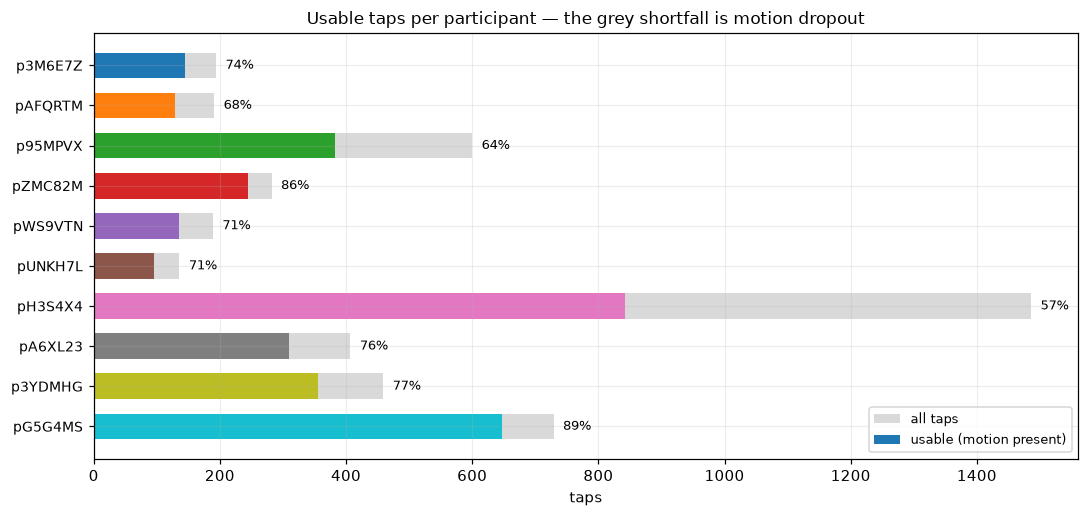

In [14]:
avail = coverage.groupby('p').agg(sessions=('session', 'size'), taps=('taps', 'sum'),
                                  usable=('usable', 'sum'))
avail['usable_pct'] = (100 * avail['usable'] / avail['taps']).round(1)
avail = avail.reindex([p for p in PARTICIPANTS if p in avail.index])
print(avail.to_string())


def plot_availability(avail):
    fig, ax = plt.subplots(figsize=(10, 4.8))
    y = np.arange(len(avail))
    ax.barh(y, avail['taps'], color='0.85', height=0.64, label='all taps')
    ax.barh(y, avail['usable'], color=[pcolor(p) for p in avail.index], height=0.64,
            label='usable (motion present)')
    for i, (p, r) in enumerate(avail.iterrows()):
        ax.text(r['taps'] + 15, i, f"{r['usable_pct']:.0f}%", va='center', fontsize=8.5)
    ax.set_yticks(y); ax.set_yticklabels(avail.index, fontsize=9); ax.invert_yaxis()
    ax.set_xlabel("taps")
    ax.set_title("Usable taps per participant — the grey shortfall is motion dropout")
    ax.legend(fontsize=8.5, loc='lower right')
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_availability(avail)

## 15. Data-quality notes and rejected derivations

- **~30% of taps are unusable** because they fall in motion-dropout stretches (Section 3).
  This is the hard ceiling on the modality and the reason it needs an availability gate
  rather than a fixed fusion weight.
- **`latency_ms` is sampling-limited.** At 20 Hz, peak latency resolves to about one sample,
  so most of its variation between people is quantisation rather than behaviour (Section 2).
  If the motion rate is ever raised, this is the first feature to re-test.
- **The impact transient itself is unrecoverable.** What is measured is the handset's
  low-frequency ring-down envelope, not the millisecond-scale strike.
- **Amplitude features are the most exposed to the handset confound** (Section 13). Ratio
  features are structurally safer because a ratio divides sensor gain out.
- **`snr` was an attempt to cancel sensor gain** by normalising each impulse against its own
  epoch noise floor. Section 13 reports whether that worked rather than assuming it.
- **This is its own modality.** Not a touch feature and not a motion feature — the coupling of
  the two, and it fails independently of both. Motion dropout kills it while leaving touch
  timing perfectly intact.

## 16. Per-participant cards

In [15]:
card = pd.DataFrame(index=PARTICIPANTS)
card['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
card['usable_taps'] = avail['usable']
card['usable_pct'] = avail['usable_pct']
for f in FEATURES:
    card[f] = FEAT.groupby('participantId')[f].median().reindex(PARTICIPANTS).round(3)
print("Blank cells mean the quantity could not be computed for that person.\n")
print(card.to_string())

Blank cells mean the quantity could not be computed for that person.

         sessions  usable_taps  usable_pct   peak  impulse_auc  latency_ms  decay_ratio  z_share    snr
p3M6E7Z         1          144        74.2  0.759       85.891        73.0        0.046    0.572  9.111
pAFQRTM         1          129        67.5  0.343       37.293        77.0       -0.033    0.554  4.214
p95MPVX         3          383        63.8  0.354       34.897        73.0       -0.005    0.521  5.818
pZMC82M         1          244        86.5  0.479       51.787       197.0       -0.081    0.574  2.572
pWS9VTN         1          135        71.4  0.534       55.749        86.0       -0.067    0.440  3.158
pUNKH7L         1           96        70.6  0.241       19.591        33.0       -0.017    0.396  4.086
pH3S4X4         8          842        56.7  0.316       30.537        37.0        0.021    0.519  4.532
pA6XL23         2          310        76.2  0.349       39.939        41.0       -0.018    0.497  

## 17. Open questions

- **The device confound is unresolved and cannot be resolved with this cohort.** Section 13
  narrows it but every participant is still on their own handset. The direct test only
  becomes possible with multi-user-per-device data: two people on one phone should still
  separate on these features, and if they do not, the amplitudes were device all along.
- **None of these features have been checked for within-person replication** in the sense
  that matters — does a person's own repeat sessions agree, relative to the between-person
  spread. Section 13 gestures at this for the device question, but it has not been run as a
  stability check on the features themselves.
- **The pre-contact steadying hypothesis failed (Section 7).** Pooled over 2,464 taps there
  is no detectable difference from control before contact. Whether that means no steadying
  exists, or that it is faster than one 50 ms sample, cannot be settled at this sampling
  rate — which makes it another item waiting on the same fix.
- **Section 13 came out the opposite way round to the prediction.** Ratio features were
  expected to be the safest and `decay_ratio` turned out the most device-like of all six.
  Either these features are largely handset properties, or tapping is genuinely very stable
  within a person; the two produce an identical signature and nothing here separates them.
- **Impulse features have not been conditioned on task type.** A tap on a small target and a
  tap on a large button are different motor acts, and the task sequence is identical across
  sessions, so this is directly testable.
- **The 20 Hz sampling limit caps everything in this notebook.** Raising it is the single
  cheapest change available — it would make `latency_ms` meaningful and might expose ring-down
  structure currently below resolution.